In [1]:
import pandas as pd

from Jupiter.Портянка import df_cleaned

In [218]:
df = pd.read_csv(r"D:\dataset_СДЕЛКИ_r-r_01-92_y_2026_q_1.csv",
                 sep='~',
                 encoding='utf-8')

print(f"Загружено строк: {len(df)}")
print(df.head())
print(f"\nНазвания столбцов: {df.columns.tolist()}")

C:\Users\Mi\AppData\Local\Temp\ipykernel_16960\3911188044.py:1: DtypeWarning: Columns (1,9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\dataset_СДЕЛКИ_r-r_01-92_y_2026_q_1.csv",


Загружено строк: 569717
   number        okato  region_code        district  \
0       4            -         30.0     Приволжский   
1       1            -         58.0  Сосновоборский   
2      18  00000000000         50.0          Мытищи   
3       2  01000000000         22.0       Алтайский   
4       1  01000000000         22.0       Алтайский   

                            city quarter_cad_number street  \
0                            NaN       30:09:050802    NaN   
1  Николо-Барнуковский сельсовет      58:26:0031202    NaN   
2                            NaN      50:12:0010209    NaN   
3                            NaN       22:02:240005    NaN   
4                            NaN       22:02:250005    NaN   

   realestate_type_code wall_material_code year_build floor    purpose_code  \
0            2001001000                NaN        NaN   NaN  141004000000.0   
1            2001001000                NaN        NaN   NaN  141001000000.0   
2            2001001000            

In [233]:
df = df[df['realestate_type_code'] == 2001003000]

In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294681 entries, 4 to 569714
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   number                294681 non-null  int64  
 1   okato                 293373 non-null  object 
 2   region_code           294679 non-null  float64
 3   district              130020 non-null  object 
 4   city                  277120 non-null  object 
 5   quarter_cad_number    294681 non-null  object 
 6   street                286022 non-null  object 
 7   realestate_type_code  294681 non-null  int64  
 8   wall_material_code    279030 non-null  object 
 9   year_build            276716 non-null  object 
 10  floor                 287408 non-null  object 
 11  purpose_code          294675 non-null  object 
 12  area                  294681 non-null  float64
 13  period_start_date     294681 non-null  object 
 14  deal_price            294681 non-null  float64
 15  curre

In [248]:
df.shape

(294675, 17)

In [299]:
pivot = df.groupby('region_code').apply(
    lambda x: x['real_deal_price'].sum() / x['real_area'].sum()
).reset_index(name='price_per_area_unit')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):

    # Отключить экспоненциальный формат для всех чисел
    pd.set_option('display.float_format', '{:.2f}'.format)  # с двумя знаками после запятой

    display(pivot)  # для Jupyter

C:\Users\Mi\AppData\Local\Temp\ipykernel_16960\542650502.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pivot = df.groupby('region_code').apply(


,region_code,price_per_area_unit
0,1,98345.90
1,10,77056.52
2,11,46173.67
3,12,81148.10
4,13,65076.96
5,14,104620.80
6,15,62534.49
7,16,144665.36
8,17,82818.17
9,18,73829.28


In [326]:
pivot = df_cleaned.groupby('region_code').apply(
    lambda x: x['real_deal_price'].sum() / x['real_area'].sum()
).reset_index(name='price_per_area_unit')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):

    # Отключить экспоненциальный формат для всех чисел
    pd.set_option('display.float_format', '{:.2f}'.format)  # с двумя знаками после запятой

    display(pivot)  # для Jupyter

C:\Users\Mi\AppData\Local\Temp\ipykernel_16960\577533366.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pivot = df_cleaned.groupby('region_code').apply(


,region_code,price_per_area_unit
0,1,101756.13
1,10,99839.29
2,11,61287.69
3,12,97260.32
4,13,86324.05
5,14,126237.14
6,15,75737.66
7,16,164392.62
8,17,105081.59
9,18,94512.31


In [324]:
df_cleaned.head()

,number,okato,region_code,district,city,quarter_cad_number,street,realestate_type_code,wall_material_code,year_build,floor,purpose_code,area,period_start_date,deal_price,currency,doc_type,real_area,real_deal_price,price_per_metr
32,1,01201802001,22,Алейский,Алейский,22:01:030901,Парковая,2001003000,061001002001,1929,01,206002000000,39.20,2026-01-01,1500000.00,рубль,ДКП,39.20,1500000.00,38265.31
65,1,01201826002,22,Алейский,Солнечный,22:01:030501,Садовая,2001003000,NaN,NaN,01,206002000000,69.20,2026-01-01,2890000.00,рубль,ДКП,69.20,2890000.00,41763.01
100,3,01202000000,22,Алтайский,NaN,22:02:250005,NaN,2001003000,061001007000,2024,1,206001000000,162.00,2026-01-01,10529500.00,рубль,ДКП,54.00,3509833.33,64996.91
144,1,01202807001,22,Алтайский,Алтайское,22:02:060003,З.Космодемьянской,2001003000,061001001001,1975,01,206002000000,67.90,2026-01-01,3500000.00,рубль,ДКП,67.90,3500000.00,51546.39
145,1,01202807001,22,Алтайский,Алтайское,22:02:060003,К.Маркса,2001003000,061001001001,1978,2,206002000000,33.50,2026-01-01,2500000.00,рубль,ДКП,33.50,2500000.00,74626.87


In [292]:
p10 = df.groupby('region_code')['real_deal_price'].transform(
    lambda x: x.quantile(0.25)
)

mask = df['real_deal_price'] >= p10

print(f'Удалится строк: {(~mask).sum():,}')
print(f'Останется строк: {mask.sum():,}')

Удалится строк: 72,866
Останется строк: 221,807


In [316]:
p99 = df_cleaned.groupby('region_code')['real_area'].transform(
    lambda x: x.quantile(0.99)
)

mask = df_cleaned['real_area'] <= p99

print(f'Удалится строк: {(~mask).sum():,}')
print(f'Останется строк: {mask.sum():,}')

Удалится строк: 0
Останется строк: 0


In [298]:
df = df[df['real_area'] >= 25]

In [ ]:
df_cleaned = df_cleaned[df_cleaned['real_area'] >= 25]

In [323]:
p10 = df.groupby('region_code')['real_deal_price'].transform(
    lambda x: x.quantile(0.25)
)

p95 = df.groupby('region_code')['real_deal_price'].transform(
    lambda x: x.quantile(0.99)
)

df_cleaned = df[
    (df['real_deal_price'] >= p10) &
    (df['real_deal_price'] <= p95)
]

In [325]:
p99 = df_cleaned.groupby('region_code')['real_area'].transform(
    lambda x: x.quantile(0.99)
)

df_cleaned = df_cleaned[df_cleaned['real_area'] <= p99
]

In [285]:
df[df['region_code'] == '78']['price_per_metr'].describe()

count    1.435300e+04
mean     1.934023e+05
std      1.450742e+05
min      6.459823e+00
25%      1.420455e+05
50%      1.922383e+05
75%      2.454212e+05
max      7.826170e+06
Name: price_per_metr, dtype: float64

In [363]:
df_fixed['real_area'] = df_fixed['area'] / df_fixed['number']

TypeError: unsupported operand type(s) for /: 'str' and 'int'

In [275]:
df['real_deal_price'] = df['deal_price'] / df['number']

In [276]:
df['price_per_metr'] = df['real_deal_price'] / df['real_area']

In [361]:
print(f'Строк с area = 0: {(df_cleaned["area"] < 25).sum()}')

Строк с area = 0: 5660


In [362]:
print(f'Строк с area = 0: {(df_cleaned["real_area"] < 25).sum()}')

Строк с area = 0: 6641


In [307]:
df['real_area'].value_counts()

real_area
44.10    976
44.00    972
43.90    959
44.40    958
43.80    949
        ... 
39.43      1
33.88      1
65.60      1
47.47      1
26.89      1
Name: count, Length: 13592, dtype: int64

In [251]:
df = df.dropna(subset=['region_code'])

In [255]:
df['region_code'] = (
    pd.to_numeric(df['region_code'], errors='coerce')
      .astype('Int64')      # nullable integer
      .astype('string')     # строковый тип pandas
)

In [111]:
df['floor'].unique()

array([nan, '2', '01', ..., '16 этаж, на отм.+49,5', 'цоколный этаж',
       'Подвал отм. -3,600'], shape=(1254,), dtype=object)

In [115]:
df['year_build'].unique()

array([nan, '2025', '1929', '1989', '2013', '1956', '1987', '1965',
       '1988', '1960', '1971', '1996', '1969', '1979', '1967', '1984',
       '1975', '1899', '2024', '2008', '2020', '2015', '1983', '2012',
       '1966', '1978', '2006', '2021', '2023', '1982', '1958', '1997',
       '1964', '2011', '1980', '1981', '1947', '1954', '1999', '1993',
       '1995', '1937', '1990', '1992', '1959', '1972', '1985', '1974',
       '1952', '1970', '2001', '2010', '2014', '2003', '2007', '1973',
       '2000', '1961', '1962', '2016', '2018', '2009', '2004', '2005',
       '2019', '1950', '1957', '1986', '1909', '1955', '1968', '1977',
       '1963', '1976', '1994', '1998', '1951', '1949', '1948', '1953',
       '1991', '1935', '2022', '2017', '1934', '1945', '1924', '2002',
       '1930', '1913', '1933', '2026', '1928', '1932', '1897', '1946',
       '1900', '1940', '1908', '1914', '1944', '1939', '1912', '1919',
       '1906', '1898', '1905', '1938', '1921', '1901', '1936', '1902',
       '1

In [327]:
df = df_cleaned

In [328]:
df = df.drop(columns=['currency'])
df = df.drop(columns=['floor'])
df = df.drop(columns=['year_build'])
df = df.drop(columns=['okato'])




In [329]:
df[df['deal_price'] == 0]['realestate_type_code'].value_counts()

Series([], Name: count, dtype: int64)

In [330]:
df['period_start_date'] = pd.to_datetime(df['period_start_date'])

In [331]:
import re

text = '''Назначение помещений 206002000000 Жилое помещение
Назначение помещений 206001000000 Нежилое помещение
Назначение зданий 204001000000 Нежилое здание
Назначение зданий 204002000000 Жилой дом
Назначение зданий 204001000000 Нежилое здание
Назначение зданий 204005000000 Садовый дом
Назначение зданий 204003000000 Многоквартирный дом
Назначение зданий 204004000000 Жилое строение
Назначение зданий 204002000000 Жилое здание
Назначение зданий 204002000000 Жилой дом
Назначение зданий 204001000000 Нежилое здание
Назначение зданий 204002000000 Жилое здание
Назначение зданий 204001000000 Нежилое здание
Классификатор видов использования земель 142002070000 Для размещения объектов среднего профессионального и высшего
профессионального образования
Классификатор видов использования земель 143005010000 Для размещения космодромов, стартовых комплексов и пусковых
Классификатор видов использования земель 144003030000 Для размещения туристических баз, стационарных и палаточных туристскооздоровительных лагерей, домов рыболова и охотника, детских туристических станций
Классификатор видов использования земель 142004000000 Для размещения объектов специального назначения
Классификатор видов использования земель 142002040100 Для размещения объектов розничной торговли
Классификатор видов использования земель 146001000000 Под водными объектами
Классификатор видов использования земель 142002000000 Для объектов общественно-делового значения
Классификатор видов использования земель 142002160000 Для размещения индивидуальных гаражей
Классификатор видов использования земель 143007000000 Для размещения иных объектов промышленности, энергетики,
транспорта, связи, радиовещания, телевидения, информатики,
обеспечения космической деятельности, обороны, безопасности и иного
Классификатор видов использования земель 143003010303 специального назначения Для размещения устройств и других объектов, необходимых для
эксплуатации, содержания, строительства, реконструкции, ремонта,
развития наземных и подземных зданий, строений, сооружений,
устройств и других объектов железнодорожного транспорта
Классификатор видов использования земель 143006020000 Для размещения объектов (территорий), обеспечивающих защиту и
охрану Государственной границы Российской Федерации
Классификатор видов использования земель 142003000000 Для общего пользования (уличная сеть)
Классификатор видов использования земель 143003040200 Для размещения аэровокзалов
Классификатор видов использования земель 143003050000 Для размещения и эксплуатации объектов трубопроводного транспорта
Классификатор видов использования земель 143006020400 Для обустройства и содержания коммуникаций
Классификатор видов использования земель 143002020100 Для размещения воздушных линий электропередачи
Классификатор видов использования земель 143006010200 Для дислокации войск и сил флота
Классификатор видов использования земель 142002080000 Для размещения административных зданий
Классификатор видов использования земель 144003100000 Для размещения иных объектов (территорий) рекреационного назначения
Классификатор видов использования земель 141014000000 Для иных видов сельскохозяйственного использования
Классификатор видов использования земель 144001040000 Для размещения природных парков
Классификатор видов использования земель 144000000000 Для размещения особо охраняемых историко-культурных и природных
объектов (территорий)
Классификатор видов использования земель 143000000000 Для размещения объектов промышленности, энергетики, транспорта,
связи, радиовещания, телевидения, информатики, обеспечения
космической деятельности, обороны, безопасности и иного специального
Классификатор видов использования земель 142004030000 назначения Для размещения скотомогильников
Классификатор видов использования земель 143003030300 Для размещения иных объектов морского, внутреннего водного
Классификатор видов использования земель 143006010500 Для мест уничтожения оружия и захоронения отходов
Классификатор видов использования земель 143004030000 Для размещения подземных кабельных и воздушных линий связи и
радиофикации и их охранные зоны
Классификатор видов использования земель 143002010600 Для размещения тепловых станций
Классификатор видов использования земель 142002130000 Для размещения объектов финансового назначения
Классификатор видов использования земель 143003010300 Для размещения, эксплуатации, расширения и реконструкции строений,
зданий, сооружений, в том числе железнодорожных вокзалов,
железнодорожных станций, а также устройств и других объектов,
необходимых для эксплуатации, содержания, строительства,
реконструкции, ремонта, развития наземных и подземных зданий,
Классификатор видов использования земель 142002150000 строений, сооружений, устройств и других объектов железнодорожного Для размещения подземных или многоэтажных гаражей
Классификатор видов использования земель 143002020300 Для размещения подстанций
Классификатор видов использования земель 143003020300 Для размещения объектов дорожного сервиса в полосах отвода
Классификатор видов использования земель 142002100000 Для размещения культовых зданий
Классификатор видов использования земель 141012000000 Для размещения объектов охотничьего хозяйства
Классификатор видов использования земель 142004010000 Для размещения кладбищ
Классификатор видов использования земель 143003010100 Для размещения железнодорожных путей и их конструктивных элементов
Классификатор видов использования земель 141007000000 Для размещения древесно-кустарниковой растительности,
предназначенной для защиты земель от воздействия негативных
(вредных) природных, антропогенных и техногенных явлений
Классификатор видов использования земель 143002010300 Для размещения ядерных установок
Классификатор видов использования земель 143005060000 Для размещения центров и оборудования для подготовки космонавтов
Классификатор видов использования земель 142002050000 Для размещения объектов общественного питания
Классификатор видов использования земель 146003000000 Для размещения иных сооружений, расположенных на водных объектах
Классификатор видов использования земель 143003020100 Для размещения автомобильных дорог и их конструктивных элементов
Классификатор видов использования земель 144004010000 Для размещения объектов культурного наследия народов Российской
Федерации (памятников истории и культуры), в том числе объектов
Классификатор видов использования земель 143005020000 археологического наследия Для размещения командно-измерительных комплексов, центров и
пунктов управления полетами космических объектов, приема, хранения и
переработки информации
Классификатор видов использования земель 143003020200 Для размещения полос отвода
Классификатор видов использования земель 143001010100 Для размещения производственных зданий
Классификатор видов использования земель 144003050000 Для размещения лесопарков
Классификатор видов использования земель 143001010400 Для размещения складских помещений
Классификатор видов использования земель 143002010800 Для размещения иных обслуживающих сооружений и объектов
Классификатор видов использования земель 143003040100 Для размещения аэропортов и аэродромов
Классификатор видов использования земель 141001020000 Для размещения зданий, строений, сооружений, используемых для
производства, хранения и первичной переработки сельскохозяйственной
Классификатор видов использования земель 141003000000 продукции Для ведения личного подсобного хозяйства
Классификатор видов использования земель 141010000000 Для сенокошения и выпаса скота гражданами
Классификатор видов использования земель 142002120000 Для размещения объектов делового назначения, в том числе офисных
Классификатор видов использования земель 144003070000 Для размещения детских и спортивных лагерей
Классификатор видов использования земель 142002020000 Для размещения объектов здравоохранения
Классификатор видов использования земель 143006010100 Для размещения военных организаций, учреждений и других объектов
Классификатор видов использования земель 143003000000 Для размещения объектов транспорта
Классификатор видов использования земель 142002060000 Для размещения объектов предпринимательской деятельности
Классификатор видов использования земель 143004060000 Для размещения иных объектов связи, радиовещания, телевидения,
Классификатор видов использования земель 141008000000 Для научно-исследовательских целей
Классификатор видов использования земель 143002010000 Для размещения электростанций и обслуживающих сооружений и
Классификатор видов использования земель 143002010500 Для размещения хранилищ радиоактивных отходов
Классификатор видов использования земель 144001030000 Для размещения национальных парков
Классификатор видов использования земель 143001010300 Для размещения подъездных путей
Классификатор видов использования земель 143006010400 Для испытательных полигонов
Классификатор видов использования земель 141005000000 Для ведения гражданами животноводства
Классификатор видов использования земель 143003020400 Для размещения дорожных сооружений
Классификатор видов использования земель 143003040300 Для размещения взлетно-посадочных полос
Классификатор видов использования земель 143006000000 Для размещения объектов, предназначенных для обеспечения обороны и
безопасности
Классификатор видов использования земель 141004000000 Для ведения гражданами садоводства и огородничества
Классификатор видов использования земель 144001050000 Для размещения дендрологических парков
Классификатор видов использования земель 142007000000 Для иных видов использования, характерных для населенных пунктов
Классификатор видов использования земель 142004040000 Под объектами размещения отходов потребления
Классификатор видов использования земель 143003030200 Для размещения морских и речных портов, причалов, пристаней
Классификатор видов использования земель 141001000000 Для сельскохозяйственного производства
Классификатор видов использования земель 141001040000 Для размещения водных объектов
Классификатор видов использования земель 144001070000 Для размещения объектов санаторного и курортного назначения
Классификатор видов использования земель 143002010200 Для размещения атомных станций
Классификатор видов использования земель 143003030400 Для выделения береговой полосы
Классификатор видов использования земель 142002040200 Для размещения объектов оптовой торговли
Классификатор видов использования земель 143004050000 Для размещения наземных сооружений и инфраструктур спутниковой
Классификатор видов использования земель 144005000000 Для размещения иных особо охраняемых историко-культурных и
природных объектов (территорий)
Классификатор видов использования земель 143004000000 Для размещения объектов связи, радиовещания, телевидения,
Классификатор видов использования земель 143002030000 Для размещения иных объектов энергетики
Классификатор видов использования земель 143002010700 Для размещения иных типов электростанций
Классификатор видов использования земель 144001080000 Территории месторождений минеральных вод, лечебных грязей, рапы
лиманов и озер
Классификатор видов использования земель 143001010600 Для размещения культурно-бытовых зданий
Классификатор видов использования земель 143003030100 Для размещения искусственно созданных внутренних водных путей
Классификатор видов использования земель 143001010500 Для размещения административных зданий
Классификатор видов использования земель 142001030000 Для размещения объектов дошкольного, начального, общего и среднего
(полного) общего образования
Классификатор видов использования земель 143002020000 Для размещения объектов электросетевого хозяйства
Классификатор видов использования земель 144003090000 Для размещения пляжей
Классификатор видов использования земель 143001020000 Для добычи и разработки полезных ископаемых
Классификатор видов использования земель 142005000000 Для размещения коммунальных, складских объектов
Классификатор видов использования земель 143003010301 Для размещения железнодорожных вокзалов
Классификатор видов использования земель 142004020000 Для размещения крематориев
Классификатор видов использования земель 142002090000 Для размещения научно-исследовательских учреждений
Классификатор видов использования земель 142002040000 Для размещения объектов торговли
Классификатор видов использования земель 143003030000 Для размещения и эксплуатации объектов морского, внутреннего водного
Классификатор видов использования земель 142002170000 Для размещения иных объектов общественно- делового значения,
обеспечивающих жизнь граждан
Классификатор видов использования земель 143003020500 Для размещения автовокзалов и автостанций
Классификатор видов использования земель 143006010000 Для обеспечения задач обороны
Классификатор видов использования земель 142001010000 Для индивидуальной жилой застройки
Классификатор видов использования земель 144001010000 Для размещения государственных природных заповедников (в том числе
биосферных)
Классификатор видов использования земель 144003010000 Для размещения домов отдыха, пансионатов, кемпингов
Классификатор видов использования земель 143001010700 Для размещения иных сооружений промышленности
Классификатор видов использования земель 143005000000 Для размещения объектов, предназначенных для обеспечения
космической деятельности
Классификатор видов использования земель 143003020000 Для размещения и эксплуатации объектов автомобильного транспорта и
объектов дорожного хозяйства
Классификатор видов использования земель 146000000000 Для размещения объектов водного фонда
Классификатор видов использования земель 142002110000 Для стоянок автомобильного транспорта
Классификатор видов использования земель 144002000000 Для размещения объектов (территорий) природоохранного назначения
Классификатор видов использования земель 142002140000 Для размещения гостиниц
Классификатор видов использования земель 143006020600 Для размещения иных объектов для защиты и охраны Государственной
границы Российской Федерации
Классификатор видов использования земель 143006020300 Для обустройства и содержания пограничных просек
Классификатор видов использования земель 143003050400 Для размещения иных объектов трубопроводного транспорта
Классификатор видов использования земель 143003020600 Для размещения иных объектов автомобильного транспорта и дорожного
Классификатор видов использования земель 142002010000 Для размещения объектов социального и коммунально-бытового
Классификатор видов использования земель 144003040000 Для размещения туристических парков
Классификатор видов использования земель 142001040000 Для размещения иных объектов, допустимых в жилых зонах и не
перечисленных в классификаторе
Классификатор видов использования земель 143002000000 Для размещения объектов энергетики
Классификатор видов использования земель 143004020000 Для размещения кабельных, радиорелейных и воздушных линий связи и
линий радиофикации на трассах кабельных и воздушных линий связи и
радиофикации и их охранные зоны
Классификатор видов использования земель 143006010700 Для размещения иных объектов обороны
Классификатор видов использования земель 141011000000 Фонд перераспределения
Классификатор видов использования земель 142001020100 Для малоэтажной застройки
Классификатор видов использования земель 142001020300 Для многоэтажной застройки
Классификатор видов использования земель 143006020100 Для обустройства и содержания инженерно-технических сооружений и
Классификатор видов использования земель 143002020500 Для размещения других сооружений и объектов электросетевого
Классификатор видов использования земель 143001010200 Для размещения коммуникаций
Классификатор видов использования земель 141006000000 Для дачного строительства
Классификатор видов использования земель 141009000000 Для учебных целей
Классификатор видов использования земель 143002010400 Для размещения пунктов хранения ядерных материалов и радиоактивных
веществ энергетики
Классификатор видов использования земель 144001020000 Для размещения государственных природных заказников
Классификатор видов использования земель 143003060000 Для размещения и эксплуатации иных объектов транспорта
Классификатор видов использования земель 143003040000 Для размещения и эксплуатации объектов воздушного транспорта
Классификатор видов использования земель 144003080000 Для размещения скверов, парков, городских садов
Классификатор видов использования земель 143005070000 Для размещения других наземных сооружений и техники, используемых
при осуществлении космической деятельности
Классификатор видов использования земель 144003000000 Для размещения объектов (территорий) рекреационного назначения
Классификатор видов использования земель 144001100000 Для размещения иных особо охраняемых природных территорий
Классификатор видов использования земель 144001060000 Для размещения ботанических садов
Классификатор видов использования земель 145003000000 Для прочих объектов лесного хозяйства
Классификатор видов использования земель 143002010100 Для размещения гидроэлектростанций
Классификатор видов использования земель 144003060000 Для размещения учебно-туристических троп и трасс
Классификатор видов использования земель 143006030000 Для размещения иных объектов обороны и безопасности
Классификатор видов использования земель 143004010000 Для размещения эксплуатационных предприятий связи и обслуживания
Классификатор видов использования земель 143002020200 Для размещения наземных сооружений кабельных линий
Классификатор видов использования земель 147000000000 Земли запаса (неиспользуемые)
Классификатор видов использования земель 143001000000 Для размещения промышленных объектов
Классификатор видов использования земель 143006010600 Для создания запасов материальных ценностей в государственном и
мобилизационном резервах (хранилища, склады и другие)
Классификатор видов использования земель 143005030000 Для размещения баз хранения космической техники
Классификатор видов использования земель 141001010000 Для использования в качестве сельскохозяйственных угодий
Классификатор видов использования земель 144004000000 Для размещения объектов историко-культурного назначения
Классификатор видов использования земель 143005040000 Для размещения полигонов приземления космических объектов и взлетнопосадочных полос
Классификатор видов использования земель 141001030000 Для размещения внутрихозяйственных дорог и коммуникаций
Классификатор видов использования земель 141013000000 Для размещения объектов рыбного хозяйства
Классификатор видов использования земель 144001090000 Для традиционного природопользования
Классификатор видов использования земель 142002030000 Для размещения объектов культуры
Классификатор видов использования земель 143006010300 Для проведения учений и иных мероприятий
Классификатор видов использования земель 146002000000 Для размещения гидротехнических сооружений
Классификатор видов использования земель 144001000000 Для размещения особо охраняемых природных объектов (территорий)
Классификатор видов использования земель 143006020200 Для обустройства и содержания пограничных знаков
Классификатор видов использования земель 142006000000 Для размещения объектов жилищно-коммунального хозяйства
Классификатор видов использования земель 142000000000 Для размещения объектов, характерных для населенных пунктов
Классификатор видов использования земель 143003050100 Для размещения нефтепроводов
Классификатор видов использования земель 143003050300 Для размещения иных трубопроводов
Классификатор видов использования земель 143003010302 Для размещения железнодорожных станций
Классификатор видов использования земель 141002000000 Для ведения крестьянского (фермерского) хозяйства
Классификатор видов использования земель 142004050000 Под иными объектами специального назначения
Классификатор видов использования земель 142001020200 Для среднеэтажной застройки
Классификатор видов использования земель 145002000000 Для восстановления лесной растительности
Классификатор видов использования земель 143003010000 Для размещения и эксплуатации объектов железнодорожного транспорта
Классификатор видов использования земель 143004040000 Для размещения наземных и подземных необслуживаемых усилительных
пунктов на кабельных линиях связи и их охранные зоны
Классификатор видов использования земель 145000000000 Для размещения объектов лесного фонда
Классификатор видов использования земель 143003010200 Для размещения полос отвода железнодорожных путей
Классификатор видов использования земель 141000000000 Для размещения объектов сельскохозяйственного назначения и
сельскохозяйственных угодий
Классификатор видов использования земель 143003040400 Для размещения иных наземных объектов воздушного транспорта
Классификатор видов использования земель 143006020500 Для обустройства и содержания пунктов пропуска через Государственную
границу Российской Федерации
Классификатор видов использования земель 142001020400 Для иных видов жилой застройки
Классификатор видов использования земель 144003020000 Для размещения объектов физической культуры и спорта
Классификатор видов использования земель 143005050000 Для размещения объектов экспериментальной базы для отработки
космической техники
Классификатор видов использования земель 144004020000 Для размещения военных и гражданских захоронений
Классификатор видов использования земель 143001010000 Для размещения производственных и административных зданий,
строений, сооружений и обслуживающих их объектов
Классификатор видов использования земель 143003050200 Для размещения газопроводов
Классификатор видов использования земель 145001000000 Для размещения лесной растительности
Классификатор видов использования земель 143002020400 Для размещения распределительных пунктов
Классификатор видов использования земель 143001030000 Для размещения иных объектов промышленности
Классификатор видов использования земель 142001000000 Для объектов жилой застройки
Классификатор видов использования земель 142001020000 Для многоквартирной застройки'''

purpose_dict = {}

for line in text.split('\n'):
    line = ' '.join(line.split())

    m = re.search(r'(\d{12})\s+(.+)$', line)
    if m:
        code = m.group(1)
        name = m.group(2)
        purpose_dict[code] = name

In [332]:
purpose_dict

{'206002000000': 'Жилое помещение',
 '206001000000': 'Нежилое помещение',
 '204001000000': 'Нежилое здание',
 '204002000000': 'Жилое здание',
 '204005000000': 'Садовый дом',
 '204003000000': 'Многоквартирный дом',
 '204004000000': 'Жилое строение',
 '142002070000': 'Для размещения объектов среднего профессионального и высшего',
 '143005010000': 'Для размещения космодромов, стартовых комплексов и пусковых',
 '144003030000': 'Для размещения туристических баз, стационарных и палаточных туристскооздоровительных лагерей, домов рыболова и охотника, детских туристических станций',
 '142004000000': 'Для размещения объектов специального назначения',
 '142002040100': 'Для размещения объектов розничной торговли',
 '146001000000': 'Под водными объектами',
 '142002000000': 'Для объектов общественно-делового значения',
 '142002160000': 'Для размещения индивидуальных гаражей',
 '143007000000': 'Для размещения иных объектов промышленности, энергетики,',
 '143003010303': 'специального назначения Для ра

In [89]:
df = df.dropna(subset=['region_code'])
df['region_code'] = df['region_code'].astype(int)

In [334]:
object_type_dict = {
    '2001001000': 'Земельный участок',
    '2001002000': 'Здание',
    '2001003000': 'Помещение',
    '2001004000': 'Сооружение',
    '2001005000': 'Объект незавершенного строительства',
    '2001006000': 'Единый недвижимый комплекс',
    '2001007000': 'Предприятие как имущественный комплекс',
    '2001008000': 'Участок недр',
    '2001009000': 'Машино-место'
}

df['realestate_type_code'] = df['realestate_type_code'].astype(str)
df['realestate_type_code'] = df['realestate_type_code'].map(object_type_dict)


In [335]:
df['purpose_code'] = (
    pd.to_numeric(df['purpose_code'], errors='coerce')
      .astype('Int64')
)

df['purpose_code'] = df['purpose_code'].astype(str)

In [336]:
df['purpose_code'] = df['purpose_code'].map(purpose_dict)

In [337]:
df['purpose_code'].isna().sum()

np.int64(0)

In [341]:
df['purpose_code'].value_counts()

purpose_code
Жилое помещение      201010
Нежилое помещение      6185
Name: count, dtype: int64

In [352]:
df_fixed.to_csv(r"D:\Rosreestr01-26_v2.csv", index=False, encoding='utf-8-sig')

In [342]:
problematic_rows = []

for idx, row in df.iterrows():
    for col in df.columns:
        cell_value = str(row[col])
        if '\n' in cell_value or '\r' in cell_value:
            problematic_rows.append({
                'row_index': idx,
                'column': col,
                'value': repr(cell_value[:100])  # покажем первые 100 символов
            })
            break  # достаточно одной проблемы в строке

# Выводим результат
if problematic_rows:
    print(f"Найдено проблемных строк: {len(problematic_rows)}")
    for p in problematic_rows[:10]:  # первые 10
        print(f"Строка {p['row_index']}, колонка '{p['column']}': {p['value']}")
else:
    print("Проблемных строк не найдено")

Проблемных строк не найдено


In [343]:
# Создаём копию DataFrame
df_fixed = df.copy()

# Заменяем переносы строк на пробелы во всех колонках
for col in df_fixed.columns:
    df_fixed[col] = df_fixed[col].astype(str).str.replace('\n', ' ', regex=False)
    df_fixed[col] = df_fixed[col].str.replace('\r', ' ', regex=False)

In [344]:
# Удаляем все лишние кавычки или заменяем их
for col in df_fixed.columns:
    # Вариант А: Удалить все кавычки
    df_fixed[col] = df_fixed[col].astype(str).str.replace('"', '', regex=False)

    # Вариант Б: Заменить кавычки на апострофы
    # df_clean[col] = df_clean[col].astype(str).str.replace('"', "'", regex=False)

print("Кавычки удалены из всех полей")

Кавычки удалены из всех полей


In [345]:
# Находим строки с проблемными значениями
def is_problematic_price(value):
    try:
        # Пробуем преобразовать в float
        val = float(value)
        # Проверяем, не превышает ли лимит numeric(18,2)
        if abs(val) >= 10**16:  # 10,000,000,000,000,000
            return True
        # Проверяем, не слишком ли много знаков после запятой
        if isinstance(value, str) and 'e' in value.lower():
            return True
    except:
        pass
    return False

# Применяем проверку
problem_mask = df['deal_price'].astype(str).apply(is_problematic_price)
problem_rows = df[problem_mask]

print(f"Найдено проблемных строк: {len(problem_rows)}")
print(f"Индексы проблемных строк: {problem_rows.index.tolist()[:10]}")

# Посмотрим примеры
for idx, row in problem_rows.head(5).iterrows():
    print(f"Строка {idx}, deal_price: {row['deal_price']}")

Найдено проблемных строк: 0
Индексы проблемных строк: []


In [346]:
import numpy as np


# Находим и удаляем строки с некорректной ценой
def is_valid_price(value):
    try:
        num = float(value)
        # Проверяем диапазон numeric(18,2)
        return -10**16 < num < 10**16 and np.isfinite(num)
    except:
        return False

# Создаём маску валидных строк
valid_mask = df_fixed['deal_price'].apply(is_valid_price)
df_fixed = df_fixed[valid_mask]

print(f"Удалено строк: {(~valid_mask).sum()}")
print(f"Осталось строк: {len(df_fixed)}")

Удалено строк: 0
Осталось строк: 207195


In [ ]:
df_fixed = df_fixed[df_fixed['real_area'] >= 25]

In [349]:
df_fixed.head()

,number,region_code,district,city,quarter_cad_number,street,realestate_type_code,wall_material_code,purpose_code,area,period_start_date,deal_price,doc_type,real_area,real_deal_price,price_per_metr
32,1,22,Алейский,Алейский,22:01:030901,Парковая,Помещение,061001002001,Жилое помещение,39.2,2026-01-01,1500000.0,ДКП,39.2,1500000.0,38265.30612244898
65,1,22,Алейский,Солнечный,22:01:030501,Садовая,Помещение,nan,Жилое помещение,69.2,2026-01-01,2890000.0,ДКП,69.2,2890000.0,41763.00578034682
100,3,22,Алтайский,nan,22:02:250005,nan,Помещение,061001007000,Нежилое помещение,162.0,2026-01-01,10529500.0,ДКП,54.0,3509833.3333333335,64996.91358024692
144,1,22,Алтайский,Алтайское,22:02:060003,З.Космодемьянской,Помещение,061001001001,Жилое помещение,67.9,2026-01-01,3500000.0,ДКП,67.9,3500000.0,51546.391752577314
145,1,22,Алтайский,Алтайское,22:02:060003,К.Маркса,Помещение,061001001001,Жилое помещение,33.5,2026-01-01,2500000.0,ДКП,33.5,2500000.0,74626.86567164179


In [351]:
# 2. Удаляем столбцы
columns_to_drop = ['real_deal_price', 'real_area', 'price_per_metr']
df_fixed = df_fixed.drop(columns=columns_to_drop)

print(f"\nУдалены столбцы: {columns_to_drop}")
print(f"Осталось столбцов: {len(df_fixed.columns)}")
print(f"Оставшиеся столбцы: {df_fixed.columns.tolist()}")


Удалены столбцы: ['real_deal_price', 'real_area', 'price_per_metr']
Осталось столбцов: 13
Оставшиеся столбцы: ['number', 'region_code', 'district', 'city', 'quarter_cad_number', 'street', 'realestate_type_code', 'wall_material_code', 'purpose_code', 'area', 'period_start_date', 'deal_price', 'doc_type']


In [152]:
# Преобразуем в числа (нечисловые значения станут NaN)
df_fixed['number'] = pd.to_numeric(df_fixed['number'], errors='coerce')
df_fixed['deal_price'] = pd.to_numeric(df_fixed['deal_price'], errors='coerce')

# Проверяем результат
print(f"Тип number: {df_fixed['number'].dtype}")
print(f"Тип deal_price: {df_fixed['deal_price'].dtype}")
print(f"\nСтатистика number:")
print(df_fixed['number'].describe())
print(f"\nСтатистика deal_price:")
print(df_fixed['deal_price'].describe())

Тип number: int64
Тип deal_price: float64

Статистика number:
count    569708.000000
mean          1.576759
std           6.735584
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        1460.000000
Name: number, dtype: float64

Статистика deal_price:
count    5.697080e+05
mean     1.315229e+09
std      9.574032e+11
min      6.000000e-02
25%      5.000000e+05
50%      2.100000e+06
75%      5.400000e+06
max      7.223022e+14
Name: deal_price, dtype: float64


In [181]:
# 1. Удаляем строки где area = 0
initial_rows = len(df_fixed)
df_fixed = df_fixed[df_fixed['area'] != 0]
removed_rows = initial_rows - len(df_fixed)

print(f"Удалено строк с area = 0: {removed_rows}")
print(f"Осталось строк: {len(df_fixed)}")

Удалено строк с area = 0: 0
Осталось строк: 569306


In [188]:
df_fixed['real_price'] = df_fixed['deal_price'] / df_fixed['number']

In [189]:
df_fixed['area'] = pd.to_numeric(df_fixed['area'], errors='coerce')
df_fixed['real_area'] = df_fixed['area'] / df_fixed['number']

In [190]:
df_fixed['price_per_metr'] = df_fixed['real_price'] / df_fixed['real_area']

In [171]:
# Фильтруем
mask = (df_fixed['region_code'] == '72') & (df_fixed['realestate_type_code'] == 'Помещение')
filtered_df = df_fixed[mask].copy()

# Находим 99-й перцентиль
percentile_99 = filtered_df['price_per_metr'].quantile(0.99)

# Находим строки выше 99 процентиля
high_price_per_metr = filtered_df[filtered_df['price_per_metr'] > percentile_99].copy()
high_price_per_metr = high_price_per_metr.sort_values('price_per_metr', ascending=False)

# Добавляем полезные колонки
high_price_per_metr['rank'] = range(1, len(high_price_per_metr) + 1)
high_price_per_metr['above_p99'] = high_price_per_metr['price_per_metr'] - percentile_99
high_price_per_metr['pct_above_p99'] = (high_price_per_metr['price_per_metr'] / percentile_99 - 1) * 100

# Выводим полную информацию
print(f"\n{'='*120}")
print(f"АНАЛИЗ price_per_metr ВЫШЕ 99-ГО ПРОЦЕНТИЛЯ")
print(f"{'='*120}")
print(f"Группа: region_code=72, realestate_type_code='Помещение'")
print(f"Всего строк в группе: {len(filtered_df)}")
print(f"99-й перцентиль: {percentile_99:.2f}")
print(f"Найдено строк выше 99%: {len(high_price_per_metr)}")
print(f"{'='*120}\n")

# Выводим все строки с деталями
print("ДЕТАЛЬНЫЙ СПИСОК ВСЕХ СТРОК ВЫШЕ 99 ПРОЦЕНТИЛЯ:")
print("-" * 120)

# Выбираем колонки для отображения
display_cols = ['rank', 'price_per_metr', 'real_price', 'area', 'above_p99', 'pct_above_p99',
                'district', 'street', 'period_start_date']

# Если есть нужные колонки
available_cols = [col for col in display_cols if col in high_price_per_metr.columns]

print(high_price_per_metr[available_cols].to_string(index=False))

# Сохраняем полный результат
high_price_per_metr.to_excel('all_high_price_per_metr_72_rooms.xlsx', index=False)
print(f"\n\nРезультат сохранён в 'all_high_price_per_metr_72_rooms.csv'")
print(f"Всего сохранено строк: {len(high_price_per_metr)}")


АНАЛИЗ price_per_metr ВЫШЕ 99-ГО ПРОЦЕНТИЛЯ
Группа: region_code=72, realestate_type_code='Помещение'
Всего строк в группе: 4846
99-й перцентиль: 207604.19
Найдено строк выше 99%: 49

ДЕТАЛЬНЫЙ СПИСОК ВСЕХ СТРОК ВЫШЕ 99 ПРОЦЕНТИЛЯ:
------------------------------------------------------------------------------------------------------------------------
 rank  price_per_metr   real_price    area    above_p99  pct_above_p99     district               street period_start_date
    1             inf 3.821328e+06    0.00          inf            inf город Тюмень        Юрия Рогачева        2026-01-01
    2    5.002093e+12 3.611511e+14  144.40 5.002092e+12   2.409437e+09          nan             Северная        2026-01-01
    3    8.284024e+06 1.400000e+08   16.90 8.076419e+06   3.890297e+03          nan   Геологоразведчиков        2026-01-01
    4    1.683545e+06 3.703800e+06    2.20 1.475941e+06   7.109400e+02          nan       Героев космоса        2026-01-01
    5    5.208333e+05 5.000000e+

In [360]:
df_fixed['number'] = pd.to_numeric(df_fixed['number'], errors='coerce')
df_fixed[(df_fixed['region_code'] == '77') & (df_fixed['doc_type'] == 'ДДУ')]['number'].sum()


np.int64(14604)

In [185]:
mask = (df_fixed['region_code'] != '77') & (df_fixed['realestate_type_code'] == 'Помещение')

# Рассчитываем 99-й и 1-й перцентили
p99 = df_fixed.loc[mask, 'price_per_metr'].quantile(0.95)
p1 = df_fixed.loc[mask, 'price_per_metr'].quantile(0.1)

# Удаляем строки выше 99-го И ниже 1-го перцентиля
df_cleaned = df_fixed[~(mask & ((df_fixed['price_per_metr'] > p99) | (df_fixed['price_per_metr'] < p1)))]

print(f"Удалено строк выше 99-го процентиля: {(mask & (df_fixed['price_per_metr'] > p99)).sum()}")
print(f"Удалено строк ниже 1-го процентиля: {(mask & (df_fixed['price_per_metr'] < p1)).sum()}")
print(f"Всего удалено: {(mask & ((df_fixed['price_per_metr'] > p99) | (df_fixed['price_per_metr'] < p1))).sum()}")
print(f"Осталось строк: {len(df_cleaned)}")
print(f"\n1-й перцентиль: {p1:.2f}")
print(f"99-й перцентиль: {p99:.2f}")

Удалено строк выше 99-го процентиля: 13543
Удалено строк ниже 1-го процентиля: 27086
Всего удалено: 40629
Осталось строк: 528677

1-й перцентиль: 19763.01
99-й перцентиль: 213164.65


In [175]:
# 1. Удаляем строки где area = 0
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned[df_cleaned['area'] != 0]
removed_rows = initial_rows - len(df_cleaned)

print(f"Удалено строк с area = 0: {removed_rows}")
print(f"Осталось строк: {len(df_cleaned)}")

Удалено строк с area = 0: 400
Осталось строк: 563890


In [186]:
# 2. Удаляем столбцы
columns_to_drop = ['real_price', 'real_area', 'price_per_metr']
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

print(f"\nУдалены столбцы: {columns_to_drop}")
print(f"Осталось столбцов: {len(df_cleaned.columns)}")
print(f"Оставшиеся столбцы: {df_cleaned.columns.tolist()}")


Удалены столбцы: ['real_price', 'real_area', 'price_per_metr']
Осталось столбцов: 13
Оставшиеся столбцы: ['number', 'region_code', 'district', 'city', 'quarter_cad_number', 'street', 'realestate_type_code', 'wall_material_code', 'purpose_code', 'area', 'period_start_date', 'deal_price', 'doc_type']


In [187]:
df_cleaned.to_csv(r"D:\Rosreestr01-26_new.csv", index=False, encoding='utf-8-sig')

In [130]:
df_fixed.to_csv(r"D:\Rosreestr01-26.csv", index=False, encoding='utf-8-sig')


In [134]:
# Проверяем названия колонок в DataFrame
print("Колонки в DataFrame:")
print(df_fixed.columns.tolist())

# Проверяем типы данных
print("\nТипы данных в DataFrame:")
print(df_fixed.dtypes)

# Проверяем конкретную строку 2 (индекс 1, если нумерация с 0)
print("\nСтрока 2 (индекс 1):")
for col in df_fixed.columns:
    print(f"{col}: {df_fixed.iloc[0][col]}")

Колонки в DataFrame:
['number', 'region_code', 'district', 'city', 'quarter_cad_number', 'street', 'realestate_type_code', 'wall_material_code', 'purpose_code', 'area', 'period_start_date', 'deal_price', 'doc_type']

Типы данных в DataFrame:
number                  object
region_code             object
district                object
city                    object
quarter_cad_number      object
street                  object
realestate_type_code    object
wall_material_code      object
purpose_code            object
area                    object
period_start_date       object
deal_price              object
doc_type                object
dtype: object

Строка 2 (индекс 1):
number: 4
region_code: 30
district: Приволжский
city: nan
quarter_cad_number: 30:09:050802
street: nan
realestate_type_code: Земельный участок
wall_material_code: nan
purpose_code: Для ведения гражданами садоводства и огородничества
area: 1964.0
period_start_date: 2026-01-01
deal_price: 2200000.0
doc_type: ДКП


In [139]:
df_fixed[df_fixed['purpose_code'] == 'nan']

,number,region_code,district,city,quarter_cad_number,street,realestate_type_code,wall_material_code,purpose_code,area,period_start_date,deal_price,doc_type
23,1,22,Солонешенский,nan,22:43:080004,nan,Земельный участок,nan,nan,78780.0,2026-01-01,5000000.0,ДКП
124,1,22,Алтайский,Катунь,22:02:100002,Центральная,Здание,061001999000,nan,68.7,2026-01-01,50000.0,ДКП
464,1,22,Благовещенский,Благовещенка,22:05:050285,Плодосовхозная,Здание,061001001001,nan,289.1,2026-01-01,100000.0,ДКП
614,1,22,Волчихинский,Волчиха,22:08:011246,Кирова,Здание,061001008000,nan,18.0,2026-01-01,150000.0,ДКП
1046,1,22,Каменский,Камень-на-Оби,22:68:020601,Ново-Ярковский тракт,Здание,061001001001,nan,25.6,2026-01-01,240000.0,ДКП
...,...,...,...,...,...,...,...,...,...,...,...,...,...
569703,1,96,nan,Мелитополь,96:01:0003257,Горького,Земельный участок,nan,nan,625.0,2026-01-01,200000.0,ДКП
569704,1,96,nan,Мелитополь,96:01:0003260,Пархоменко,Земельный участок,nan,nan,775.0,2026-01-01,3000000.0,ДКП
569705,1,96,nan,Мелитополь,96:01:0003364,Зеленая,Земельный участок,nan,nan,2500.0,2026-01-01,450000.0,ДКП
569708,2,96,nan,Мелитополь,96:01:0005944,nan,Земельный участок,nan,nan,4600.0,2026-01-01,300000.0,ДКП


In [149]:
df_2[df_2['quarter_cad_number'] == '22:05:050285']

,number,okato,region_code,district,city,quarter_cad_number,street,realestate_type_code,wall_material_code,year_build,floor,purpose_code,area,period_start_date,deal_price,currency,doc_type
464,1,01205551000,22.0,Благовещенский,Благовещенка,22:05:050285,Плодосовхозная,2001002000,061001001001,1975,1,204006000000.0,289.1,2026-01-01,100000.0,рубль,ДКП


Статистика price_per_metr:
count    5.693060e+05
mean     8.876152e+06
std      6.629483e+09
min      2.497515e-05
25%      1.718984e+03
50%      3.267974e+04
75%      9.838650e+04
max      5.002093e+12
Name: price_per_metr, dtype: float64
0.1%: 0.01 руб/кв.м
0.5%: 0.13 руб/кв.м
1.0%: 0.69 руб/кв.м
2.0%: 3.14 руб/кв.м
5.0%: 30.33 руб/кв.м
10.0%: 161.81 руб/кв.м
20.0%: 849.56 руб/кв.м
30.0%: 3809.52 руб/кв.м


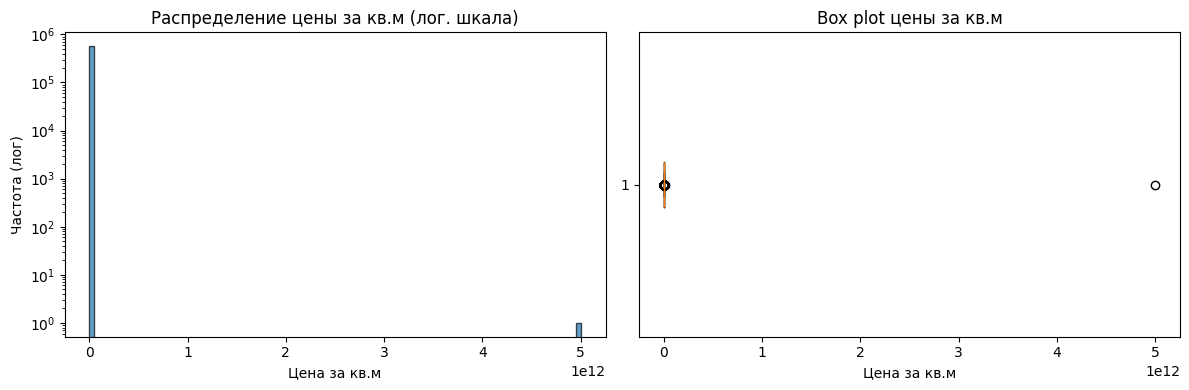

In [193]:
# Анализ распределения
import matplotlib.pyplot as plt

# Смотрим статистику
print("Статистика price_per_metr:")
print(df_fixed['price_per_metr'].describe())

# Смотрим процентили
percentiles = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
for p in percentiles:
    value = df_fixed['price_per_metr'].quantile(p)
    print(f"{p*100:0.1f}%: {value:.2f} руб/кв.м")

# Визуализируем хвост распределения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма с логарифмической шкалой
axes[0].hist(df_fixed['price_per_metr'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_title('Распределение цены за кв.м (лог. шкала)')
axes[0].set_xlabel('Цена за кв.м')
axes[0].set_ylabel('Частота (лог)')

# Box plot
axes[1].boxplot(df_fixed['price_per_metr'], vert=False)
axes[1].set_title('Box plot цены за кв.м')
axes[1].set_xlabel('Цена за кв.м')

plt.tight_layout()
plt.show()

In [195]:
df_cleaned['real_price'] = df_cleaned['deal_price'] / df_cleaned['number']
df_cleaned['real_area'] = df_cleaned['area'] / df_cleaned['number']
df_cleaned['price_per_metr'] = df_cleaned['real_price'] / df_cleaned['real_area']


In [215]:
df_2_78 = df_2[df_2['region_code'] == 78.0]

In [216]:
df_2_78

,number,okato,region_code,district,city,quarter_cad_number,street,realestate_type_code,wall_material_code,year_build,floor,purpose_code,area,period_start_date,deal_price,currency,doc_type
220075,4,40000000000,78.0,муниципальный округ Ланское,NaN,78:34:0004017,Белоостровская,2001009000,NaN,NaN,NaN,NaN,57.50,2026-01-01,7.711400e+06,рубль,ДКП
220076,18,40000000000,78.0,муниципальный округ Морской,NaN,78:06:0002923,NaN,2001003000,NaN,NaN,NaN,206001000000.0,1770.09,2026-01-01,4.494772e+08,рубль,ДДУ
220077,25,40000000000,78.0,муниципальный округ Морской,NaN,78:06:0002923,NaN,2001003000,NaN,NaN,NaN,206002000000.0,1769.76,2026-01-01,5.828231e+08,рубль,ДДУ
220078,8,40000000000,78.0,муниципальный округ Морской,NaN,78:06:0002923,NaN,2001009000,NaN,NaN,NaN,206001000000.0,106.00,2026-01-01,1.541500e+07,рубль,ДДУ
220079,1,40000000000,78.0,муниципальный округ Народный,Красный Октябрь,78:12:0006351,5-я,2001001000,NaN,NaN,NaN,141004000000.0,393.00,2026-01-01,3.200000e+06,рубль,ДКП
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569515,2,NaN,78.0,NaN,NaN,78:14:0007677,Орджоникидзе,2001003000,061001007000;061001006000,2023,15,206001000000.0,29.40,2026-01-01,9.285023e+06,рубль,ДКП
569516,1,NaN,78.0,NaN,NaN,78:14:0007677,Орджоникидзе,2001003000,061001007000;061001006000,2023,26,206001000000.0,13.70,2026-01-01,5.136180e+06,рубль,ДКП
569517,1,NaN,78.0,NaN,NaN,78:14:0007677,Орджоникидзе,2001003000,061001007000;061001006000,2023,5,206001000000.0,15.50,2026-01-01,5.725700e+06,рубль,ДКП
569518,2,NaN,78.0,NaN,NaN,78:42:0018222,NaN,2001001000,NaN,NaN,NaN,142001010000.0,1202.00,2026-01-01,1.002000e+07,рубль,ДКП


In [217]:
df_2_78.to_excel(r"D:\Rosreestr-2-78.xlsx", index=False)